## SVM Model

We use a Support Vector Machine (SVM), a supervised classifier that separates classes by finding the boundary (hyperplane) that maximizes the margin between them. For data that isn't linearly separable, SVM uses the kernel trick to project the features into a higher-dimensional space where a separating boundary may exist.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

X_train = pd.read_csv('/Users/jenniferlee/Downloads/ECS171/ECS-171_Research_Project/data/X_train_scaled.csv')
X_test  = pd.read_csv('/Users/jenniferlee/Downloads/ECS171/ECS-171_Research_Project/data/X_test_scaled.csv')
Y_train = pd.read_csv('/Users/jenniferlee/Downloads/ECS171/ECS-171_Research_Project/data/Y_train.csv').values.ravel()
Y_test  = pd.read_csv('/Users/jenniferlee/Downloads/ECS171/ECS-171_Research_Project/data/Y_test.csv').values.ravel()

label_encoder = joblib.load('/Users/jenniferlee/Downloads/ECS171/ECS-171_Research_Project/data/label_encoder.pkl')

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('Y_train:', Y_train.shape)
print('Y_test: ', Y_test.shape)
print('Classes:', label_encoder.classes_)

X_train: (5533, 11)
X_test:  (1384, 11)
Y_train: (5533,)
Y_test:  (1384,)
Classes: ['edm' 'hiphop' 'latin' 'pop' 'r&b' 'rap' 'rock']


#### Baseline SVM (RBF kernel)
Before tuning, we train a baseline SVM with scikit-learn's defaults (RBF kernel, `C=1.0`, `gamma='scale'`) to establish a reference accuracy.

In [2]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

baseline_svm = SVC(kernel='rbf', random_state=0)
baseline_svm.fit(X_train, Y_train)

Y_pred_baseline = baseline_svm.predict(X_test)

baseline_train_acc = accuracy_score(Y_train, baseline_svm.predict(X_train))
baseline_test_acc  = accuracy_score(Y_test, Y_pred_baseline)

print(f'Baseline SVM (C=1.0, gamma=scale)')
print(f'Training accuracy: {baseline_train_acc:.4f}')
print(f'Test accuracy: {baseline_test_acc:.4f}')

Baseline SVM (C=1.0, gamma=scale)
Training accuracy: 0.6044
Test accuracy: 0.5145


#### Hyperparameter Tuning
We run a single grid search over all three kernels and their relevant parameters. GridSearchCV does 5-fold cross-validation on the training set for every combination and picks the one with the best mean CV accuracy.

The following are the hyperparameters that we test:
- **kernel:** defines the function used to transform data for separating classes; `linear` (straight), `rbf` (curved, general-purpose), `poly` (curved, flexibility set by `degree`).
- **C:** controls the trade-off between a wider margin (low C, risk underfitting) and correctly classifying all points (high C, risk overfitting).
- **gamma:** controls the influence of data points; high `gamma` leads to tight boundary that risks overfitting.
- **degree:** polynomial degree; high degree creates more complex curves but risks overfitting.

In [3]:
from sklearn.model_selection import GridSearchCV

grid = [
    {'kernel': ['rbf'],    'C': [0.1, 1, 10], 'gamma': ['scale', 1, 0.1, 0.01]},
    {'kernel': ['poly'],   'C': [0.1, 1, 10], 'gamma': ['scale', 1, 0.1, 0.01], 'degree': [2, 3]},
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
]

grid_search = GridSearchCV(
    SVC(random_state=0),
    grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, Y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best cross validation accuracy: {grid_search.best_score_:.4f}')

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross validation accuracy: 0.5444


#### Tracking Accuracy Across C and gamma

We visualize how the CV accuracy varied across the grid. We plot CV accuracy as a function of C, with one line per kernel/gamma/degree combination.

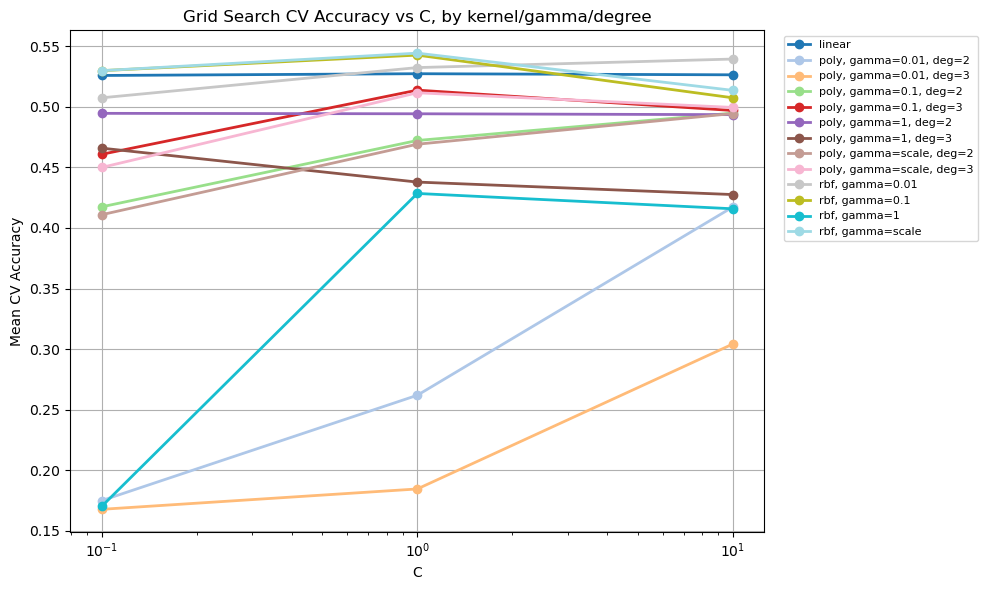

In [4]:
results = pd.DataFrame(grid_search.cv_results_)

# build a readable label for each non-C combination
def label_row(row):
    parts = [row['param_kernel']]

    if pd.notna(row.get('param_gamma')):
        parts.append(f"gamma={row['param_gamma']}")

    if pd.notna(row.get('param_degree')):
        parts.append(f"deg={int(row['param_degree'])}")

    return ', '.join(parts)

results['combo'] = results.apply(label_row, axis=1)

# unique combos
combos = sorted(results['combo'].unique())

# generate enough visually distinct colors
cmap = plt.colormaps['tab20']
colors = [cmap(i / max(len(combos) - 1, 1)) for i in range(len(combos))]

# map each combo to a unique color
color_map = dict(zip(combos, colors))

plt.figure(figsize=(10, 6))

for combo in combos:
    sub = results[results['combo'] == combo].sort_values('param_C')

    plt.plot(
        sub['param_C'].astype(float),
        sub['mean_test_score'],
        marker='o',
        linewidth=2,
        color=color_map[combo],
        label=combo
    )

plt.xscale('log')

plt.title("Grid Search CV Accuracy vs C, by kernel/gamma/degree")
plt.xlabel("C")
plt.ylabel("Mean CV Accuracy")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=8
)

plt.grid(True)
plt.tight_layout()
plt.show()

To check whether the best model is under/overfitting, we sweep each of the RBF kernel's two hyperparameters one at a time (holding the other at the best model's value) and plot train vs. test accuracy. `C` and `gamma` are swept on a log scale because they act multiplicatively.

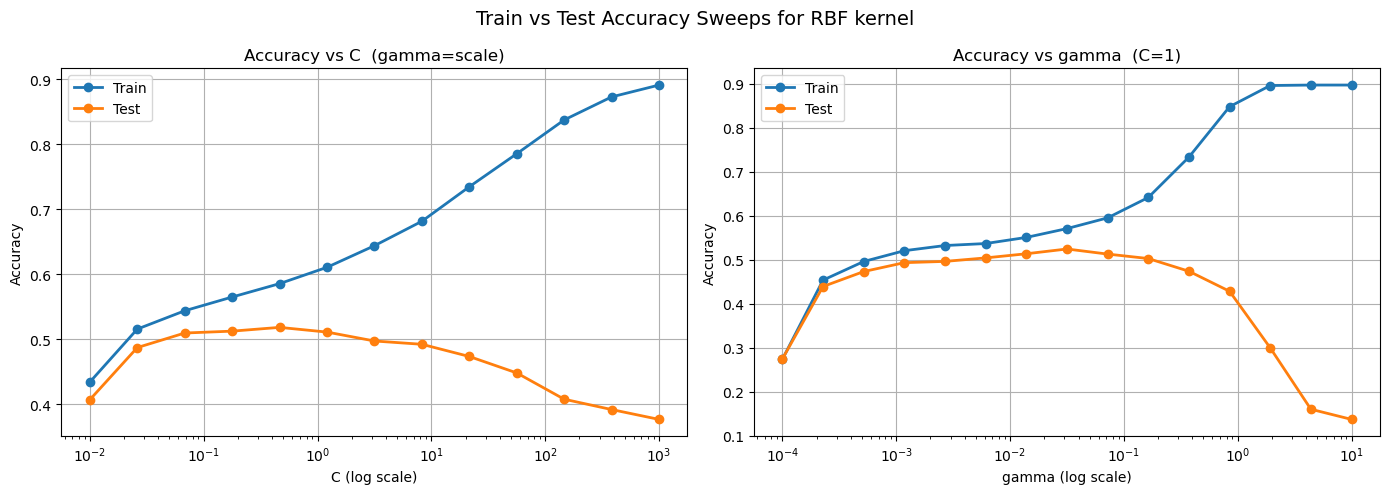

C sweep highest test accuracy: 0.5181 at C = 0.4642
gamma sweep highest test accuracy: 0.5246 at gamma = 0.03162


In [5]:
best_kernel = grid_search.best_params_['kernel']
best_C      = grid_search.best_params_['C']
best_gamma  = grid_search.best_params_['gamma']   # 'scale'
extra = {'degree': grid_search.best_params_['degree']} if best_kernel == 'poly' else {}

# sweep one parameter at a time, holding the other at the best model's value
C_sweep     = np.logspace(-2, 3, 13)   # 0.01 ... 1000
gamma_sweep = np.logspace(-4, 1, 15)   # 0.0001 ... 10

def sweep(param, values, fixed):
    train, test = [], []
    for v in values:
        model = SVC(kernel=best_kernel, random_state=0, **{param: v}, **fixed, **extra)
        model.fit(X_train, Y_train)
        train.append(accuracy_score(Y_train, model.predict(X_train)))
        test.append(accuracy_score(Y_test,  model.predict(X_test)))
    return train, test

def plot_sweep(ax, values, train, test, title, xlabel):
    ax.plot(values, train, marker='o', linewidth=2, label='Train')
    ax.plot(values, test,  marker='o', linewidth=2, label='Test')
    ax.set_xscale('log')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

C_train, C_test = sweep('C', C_sweep, {'gamma': best_gamma})
plot_sweep(axes[0], C_sweep, C_train, C_test,
           f'Accuracy vs C  (gamma={best_gamma})', 'C (log scale)')

g_train, g_test = sweep('gamma', gamma_sweep, {'C': best_C})
plot_sweep(axes[1], gamma_sweep, g_train, g_test,
           f'Accuracy vs gamma  (C={best_C})', 'gamma (log scale)')

fig.suptitle(f'Train vs Test Accuracy Sweeps for {best_kernel.upper()} kernel', fontsize=14)
plt.tight_layout()
plt.show()

bi = int(np.argmax(C_test))
gi = int(np.argmax(g_test))
print(f'C sweep highest test accuracy: {C_test[bi]:.4f} at C = {C_sweep[bi]:.4g}')
print(f'gamma sweep highest test accuracy: {g_test[gi]:.4f} at gamma = {gamma_sweep[gi]:.4g}')

#### Best Model Evaluation
Macro averaging treats all the music genres equally despite them not being perfectly balanced.

Best SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Training accuracy: 0.6044
Test accuracy: 0.5145

              precision    recall  f1-score   support

         edm       0.60      0.60      0.60       191
      hiphop       0.51      0.52      0.52       194
       latin       0.52      0.48      0.50       207
         pop       0.42      0.51      0.46       233
         r&b       0.40      0.34      0.36       146
         rap       0.41      0.38      0.40       185
        rock       0.70      0.69      0.70       228

    accuracy                           0.51      1384
   macro avg       0.51      0.50      0.50      1384
weighted avg       0.52      0.51      0.51      1384



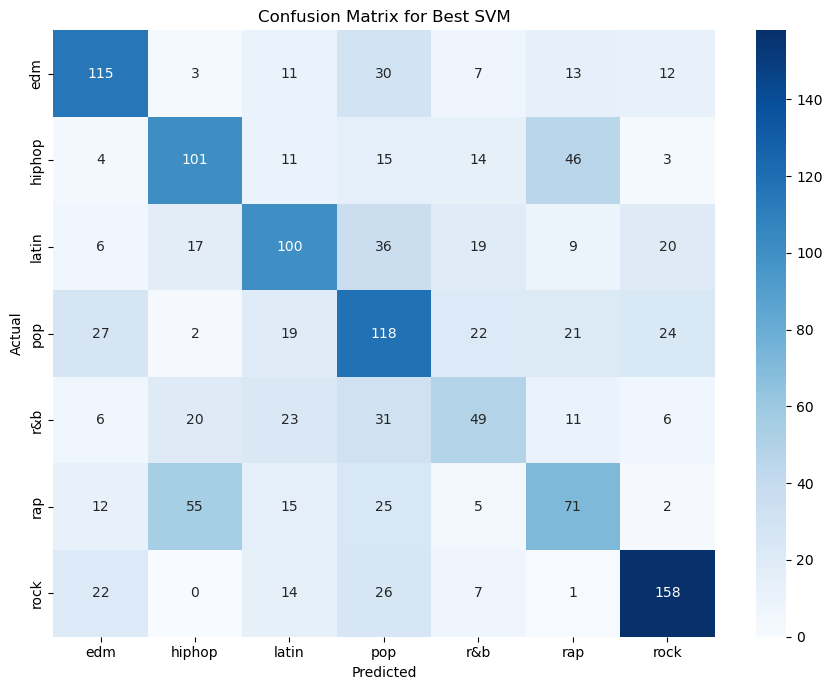

In [6]:
import seaborn as sns

best_svm = grid_search.best_estimator_

Y_pred = best_svm.predict(X_test)

train_acc = accuracy_score(Y_train, best_svm.predict(X_train))
test_acc  = accuracy_score(Y_test, Y_pred)

print(f'Best SVM: {grid_search.best_params_}')
print(f'Training accuracy: {train_acc:.4f}')
print(f'Test accuracy: {test_acc:.4f}')
print()
print(classification_report(Y_test, Y_pred, target_names=label_encoder.classes_))

# confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f'Confusion Matrix for Best SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#### Top-3 Accuracy
Because the genres overlap so heavily, a strict top-1 score may understate how useful the model is. Top-3 accuracy counts a prediction as correct if the true genre is among the model's three highest-scoring classes. To rank the classes we use `predict_proba`, which requires refitting the best configuration with `probability=True`.

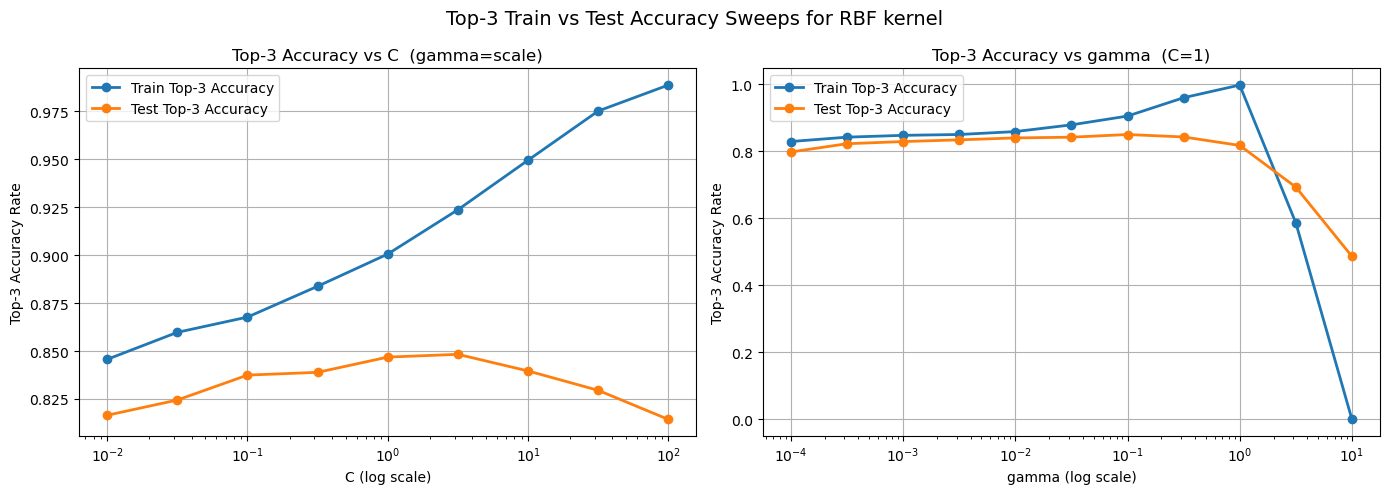

C sweep highest Top-3 test accuracy: 0.8483 at C = 3.162
gamma sweep highest Top-3 test accuracy: 0.8497 at gamma = 0.1


In [7]:
from sklearn.metrics import top_k_accuracy_score

# sweep each RBF knob one at a time, holding the other at the best model's value
C_values     = np.logspace(-2, 2, 9)    # 0.01 ... 100
gamma_values = np.logspace(-4, 1, 11)   # 0.0001 ... 10

def top3_sweep(param, values, fixed):
    train, test = [], []
    for v in values:
        svm = SVC(kernel=best_kernel, probability=True, random_state=0,
                  **{param: v}, **fixed, **extra)
        svm.fit(X_train, Y_train)
        train.append(top_k_accuracy_score(Y_train, svm.predict_proba(X_train), k=3))
        test.append(top_k_accuracy_score(Y_test,  svm.predict_proba(X_test),  k=3))
    return train, test

def plot_sweep(ax, values, train, test, title, xlabel):
    ax.plot(values, train, marker='o', linewidth=2, label='Train Top-3 Accuracy')
    ax.plot(values, test,  marker='o', linewidth=2, label='Test Top-3 Accuracy')
    ax.set_xscale('log')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Top-3 Accuracy Rate')
    ax.legend()
    ax.grid(True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

C_train, C_test = top3_sweep('C', C_values, {'gamma': best_gamma})
plot_sweep(axes[0], C_values, C_train, C_test,
           f'Top-3 Accuracy vs C  (gamma={best_gamma})', 'C (log scale)')

g_train, g_test = top3_sweep('gamma', gamma_values, {'C': best_C})
plot_sweep(axes[1], gamma_values, g_train, g_test,
           f'Top-3 Accuracy vs gamma  (C={best_C})', 'gamma (log scale)')

fig.suptitle(f'Top-3 Train vs Test Accuracy Sweeps for {best_kernel.upper()} kernel', fontsize=14)
plt.tight_layout()
plt.show()

bi = int(np.argmax(C_test))
gi = int(np.argmax(g_test))
print(f'C sweep highest Top-3 test accuracy: {C_test[bi]:.4f} at C = {C_values[bi]:.4g}')
print(f'gamma sweep highest Top-3 test accuracy: {g_test[gi]:.4f} at gamma = {gamma_values[gi]:.4g}')